# MySpotify -- Dataset Exploration
Million Song Dataset (MSD) -- parsing and EDA for all 4 files.

**Files expected** (local folder, Kaggle input mount, or Kaggle download fallback):
- `p02_unique_tracks.txt`
- `p02_msd_tagtraum_cd2.cls`
- `p02_train_triplets.txt` (unzipped)
- `p02_mxm_dataset_train.txt` (unzipped)

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from src.data import MySpotifyRecommender

In [2]:
rs = MySpotifyRecommender.from_files(Path.cwd().parent / "data", download=True, triplets_sample_rows=100_000)

  tracks      (1000000, 4)
  genres      (280831, 3)
  triplets    (100000, 3)
  lyrics_long (16845943, 3)


In [3]:
print(rs.genres.head(10))
print(rs.triplets.head(10))
print(rs.tracks.head(10))
print(rs.lyrics_long.head(10))

shape: (10, 3)
┌────────────────────┬────────────────┬────────────────┐
│ track_id           ┆ majority_genre ┆ minority_genre │
│ ---                ┆ ---            ┆ ---            │
│ str                ┆ str            ┆ str            │
╞════════════════════╪════════════════╪════════════════╡
│ TRAAAAK128F9318786 ┆ Rock           ┆ null           │
│ TRAAAAW128F429D538 ┆ Rap            ┆ null           │
│ TRAAABD128F429CF47 ┆ Rock           ┆ RnB            │
│ TRAAADJ128F4287B47 ┆ Rock           ┆ null           │
│ TRAAADZ128F9348C2E ┆ Latin          ┆ null           │
│ TRAAAED128E0783FAB ┆ Jazz           ┆ null           │
│ TRAAAEF128F4273421 ┆ Rock           ┆ null           │
│ TRAAAEM128F93347B9 ┆ Electronic     ┆ null           │
│ TRAAAFD128F92F423A ┆ Punk           ┆ Rock           │
│ TRAAAGF12903CEC202 ┆ Pop            ┆ null           │
└────────────────────┴────────────────┴────────────────┘
shape: (10, 3)
┌─────────────────────────────────┬────────────────────┬──

## 1. Tracks

In [4]:
print(f"Tracks shape: {rs.tracks.shape}")
print(f"Unique artists: {rs.tracks['artist'].n_unique()}")
rs.tracks.head(10)

Tracks shape: (1000000, 4)
Unique artists: 72665


track_id,song_id,artist,title
str,cat,str,str
"""TRMMMYQ128F932D901""","""SOQMMHC12AB0180CB8""","""Faster Pussy cat""","""Silent Night"""
"""TRMMMKD128F425225D""","""SOVFVAK12A8C1350D9""","""Karkkiautomaatti""","""Tanssi vaan"""
"""TRMMMRX128F93187D9""","""SOGTUKN12AB017F4F1""","""Hudson Mohawke""","""No One Could Ever"""
"""TRMMMCH128F425532C""","""SOBNYVR12A8C13558C""","""Yerba Brava""","""Si Vos Querés"""
"""TRMMMWA128F426B589""","""SOHSBXH12A8C13B0DF""","""Der Mystic""","""Tangle Of Aspens"""
"""TRMMMXN128F42936A5""","""SOZVAPQ12A8C13B63C""","""David Montgomery""","""Symphony No. 1 G minor ""Sinfon…"
"""TRMMMLR128F1494097""","""SOQVRHI12A6D4FB2D7""","""Sasha / Turbulence""","""We Have Got Love"""
"""TRMMMBB12903CB7D21""","""SOEYRFT12AB018936C""","""Kris Kross""","""2 Da Beat Ch'yall"""
"""TRMMMHY12903CB53F1""","""SOPMIYT12A6D4F851E""","""Joseph Locke""","""Goodbye"""


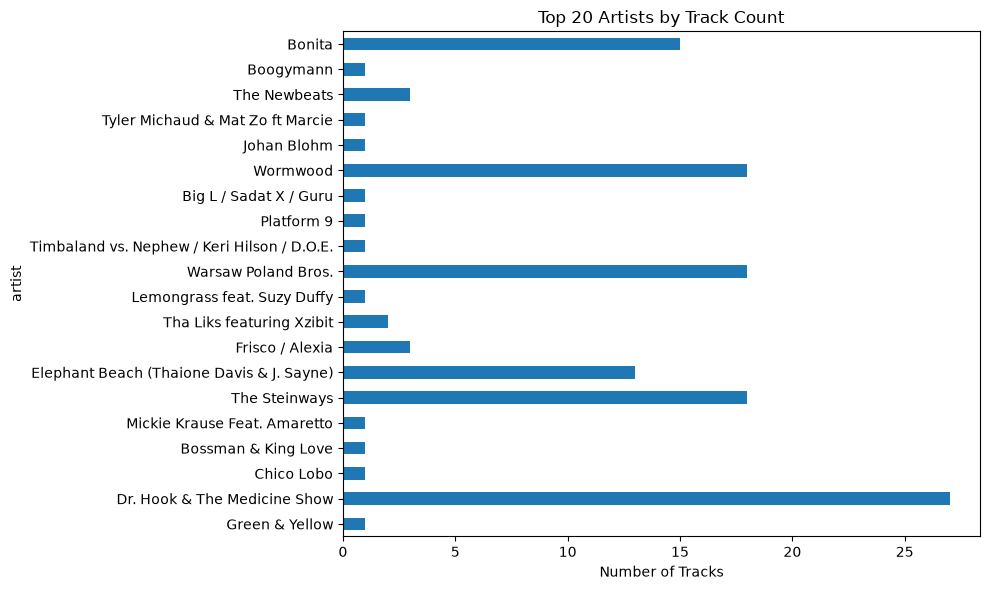

In [5]:
top_artists = rs.tracks["artist"].value_counts().head(20).to_pandas().set_index("artist")["count"]
top_artists.plot(kind="barh", figsize=(10, 6), title="Top 20 Artists by Track Count")
plt.xlabel("Number of Tracks")
plt.tight_layout()
plt.show()

## 2. Genres

In [6]:
print(f"Genres shape: {rs.genres.shape}")
print(f"Unique majority genres: {rs.genres['majority_genre'].n_unique()}")
rs.genres.head()

Genres shape: (280831, 3)
Unique majority genres: 15


track_id,majority_genre,minority_genre
str,str,str
"""TRAAAAK128F9318786""","""Rock""",null
"""TRAAAAW128F429D538""","""Rap""",null
"""TRAAABD128F429CF47""","""Rock""","""RnB"""
"""TRAAADJ128F4287B47""","""Rock""",null
"""TRAAADZ128F9348C2E""","""Latin""",null


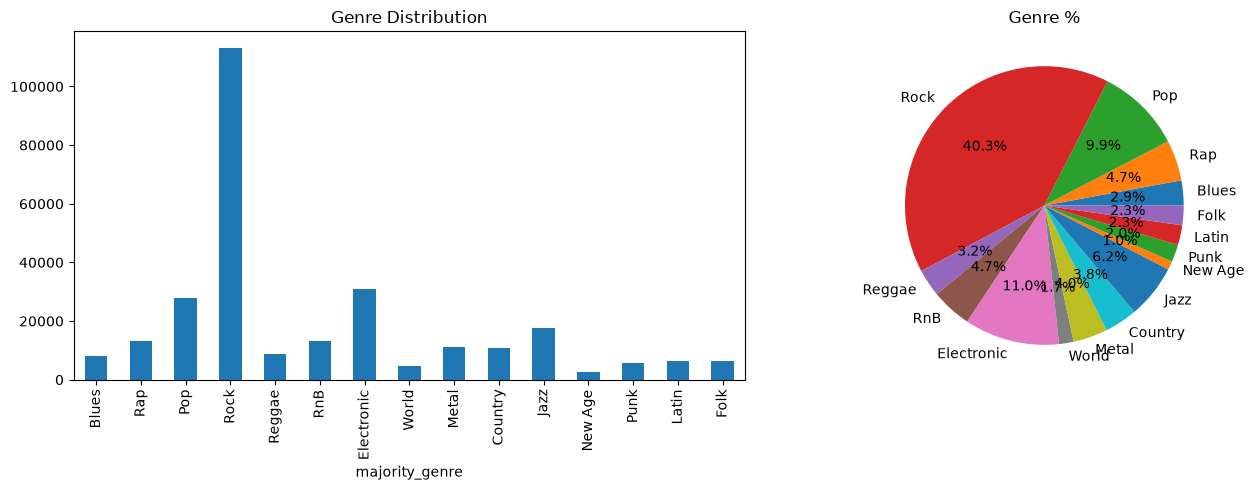

In [7]:
genre_counts = rs.genres["majority_genre"].value_counts().to_pandas().set_index("majority_genre")["count"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
genre_counts.plot(kind="bar", ax=axes[0], title="Genre Distribution")
genre_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", title="Genre %")
axes[1].set(ylabel="")
plt.tight_layout()
plt.show()

## 3. Triplets (User-Song Interactions)

In [8]:
print(f"Triplets shape: {rs.triplets.shape}")
print(f"Unique users: {rs.triplets['user_id'].n_unique()}")
print(f"Unique songs: {rs.triplets['song_id'].n_unique()}")
print(f"Mean play count: {rs.triplets['play_count'].mean():.2f}")
print(f"Max play count: {rs.triplets['play_count'].max()}")

Triplets shape: (100000, 3)
Unique users: 2042
Unique songs: 44458
Mean play count: 2.90
Max play count: 1890


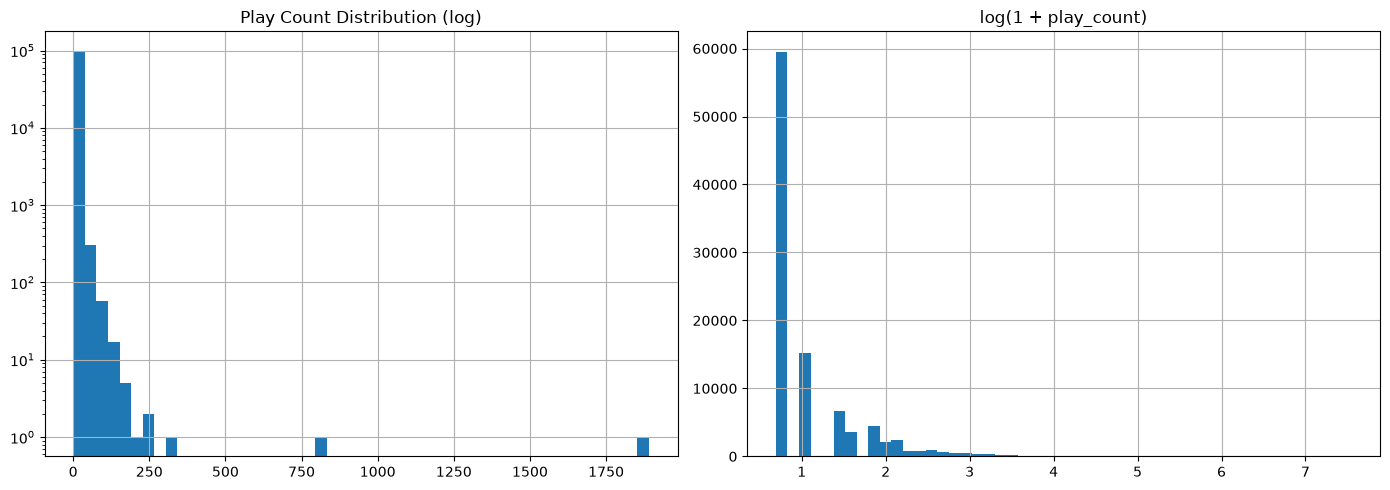

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rs.triplets["play_count"].to_pandas().hist(bins=50, ax=axes[0], log=True)
axes[0].set_title("Play Count Distribution (log)")
np.log1p(rs.triplets["play_count"].to_pandas()).hist(bins=50, ax=axes[1])
axes[1].set_title("log(1 + play_count)")
plt.tight_layout()
plt.show()

## 4. Lyrics (Bag-of-Words)

In [10]:
print(f"Lyrics long shape: {rs.lyrics_long.shape}")
print(f"Unique tracks with lyrics: {rs.lyrics_long['track_id'].n_unique()}")
print(f"Vocabulary size: {rs.lyrics_long['word'].n_unique()}")
rs.lyrics_long.head()

Lyrics long shape: (16845943, 3)
Unique tracks with lyrics: 210519


Vocabulary size: 5000


track_id,word,count
str,str,i64
"""TRAAAAV128F421A322""","""i""",6
"""TRAAAAV128F421A322""","""the""",4
"""TRAAAAV128F421A322""","""you""",2
"""TRAAAAV128F421A322""","""to""",2
"""TRAAAAV128F421A322""","""and""",5


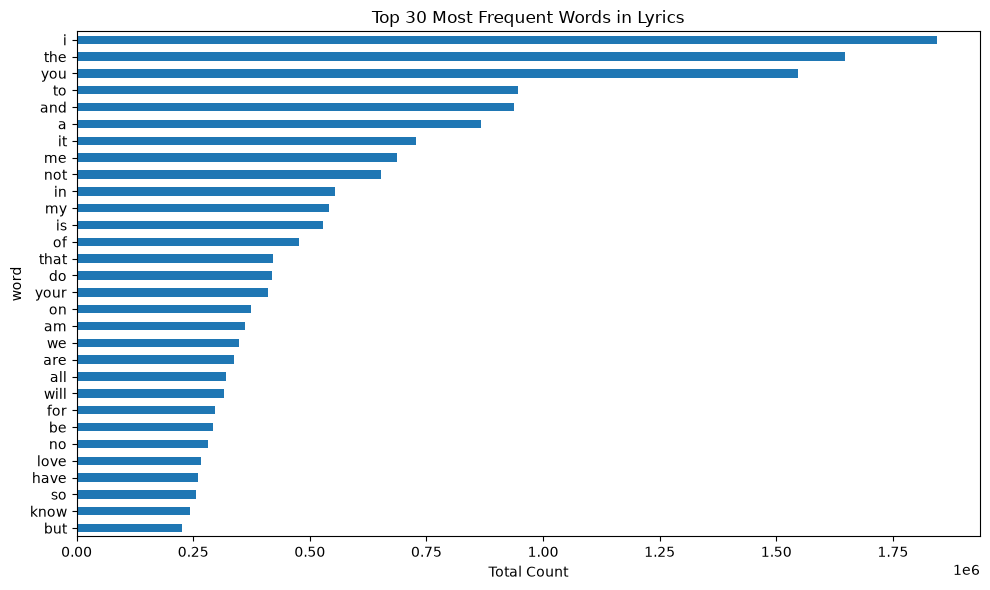

In [11]:
top_words = rs.lyrics_long.group_by("word").agg(pl.col("count").sum()).sort("count", descending=True).head(30).to_pandas().set_index("word")["count"]
top_words.plot(kind="barh", figsize=(10, 6), title="Top 30 Most Frequent Words in Lyrics")
plt.xlabel("Total Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()